## Notebook 03: Exploratory Data Analysis

### What this notebook does
Analyzes patterns in cleaned data to form hypotheses
that guide feature engineering and model selection.

### 5 analyses
1. Total sales trend over time
2. Sales by product family
3. Holiday impact on sales
4. Oil price vs total sales
5. Seasonality decomposition

### Output
5 written findings explaining why each feature matters

In [1]:
#Load data:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

df = pd.read_parquet("../data/processed/master_sample.parquet")

print(f"Loaded: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Stores: {df['store_nbr'].nunique()}")
print(f"Families: {df['family'].nunique()}")

Loaded: (28234961, 14)
Date range: 2013-01-02 00:00:00 to 2017-08-15 00:00:00
Stores: 10
Families: 33


28.2M rows across 10 stores
4.5 years of data (Jan 2013 → Aug 2017)
33 product families across 10 stores

Analysis 1 — Total Sales Trend Over Time

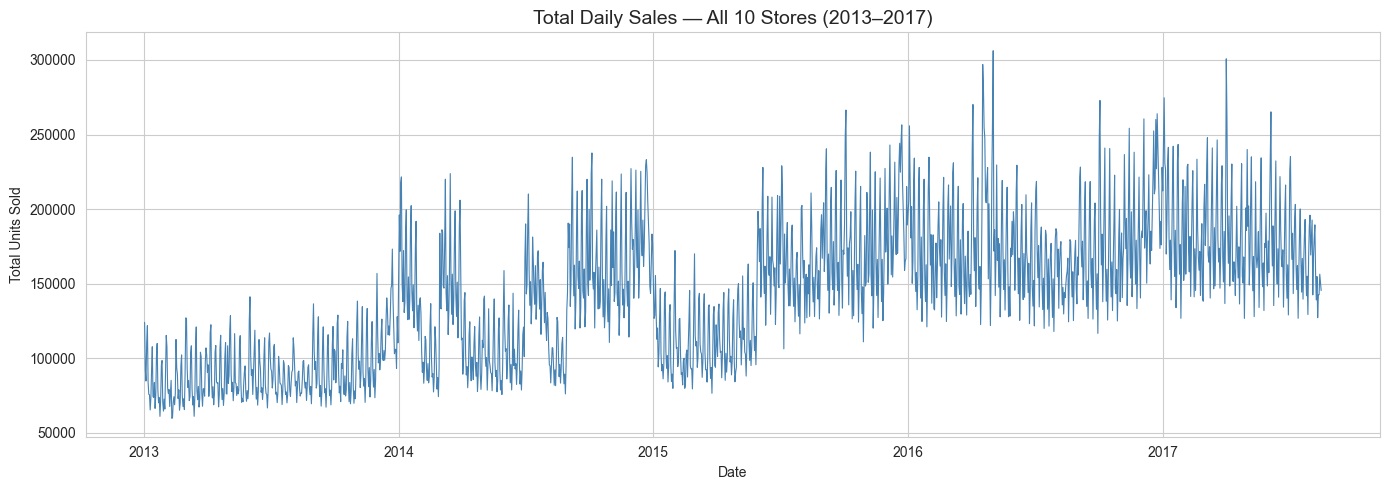

Average daily sales: 142,565 units
Max daily sales:     306,212 units
Min daily sales:     59,646 units


In [2]:
# WHY: first thing to understand is the overall trend
# Are sales growing? Shrinking? Any sudden drops or spikes?

daily_sales = (
    df.groupby("date")["unit_sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(daily_sales["date"], daily_sales["unit_sales"], 
         color="steelblue", linewidth=0.8)
plt.title("Total Daily Sales — All 10 Stores (2013–2017)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.savefig("../outputs/plot_01_sales_trend.png", dpi=100)
plt.show()

print(f"Average daily sales: {daily_sales['unit_sales'].mean():,.0f} units")
print(f"Max daily sales:     {daily_sales['unit_sales'].max():,.0f} units")
print(f"Min daily sales:     {daily_sales['unit_sales'].min():,.0f} units")

Analysis 2 — Sales by Product Family

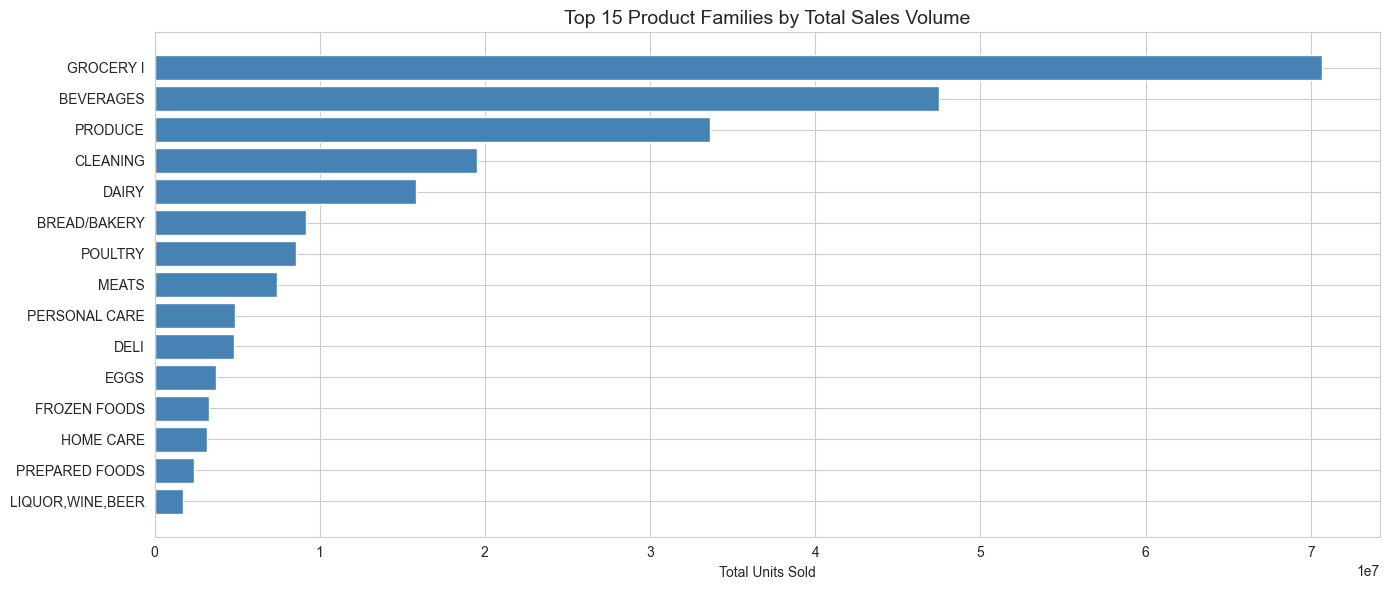

Top 5 families:
      family    unit_sales   pct
0  GROCERY I  7.066266e+07  29.5
1  BEVERAGES  4.751546e+07  19.9
2    PRODUCE  3.363709e+07  14.1
3   CLEANING  1.952251e+07   8.2
4      DAIRY  1.585650e+07   6.6

Top 5 families = 78.3% of total volume


In [3]:
# WHY: not all product families matter equally
# Top families will drive most of our forecast error
# We need to know which families to focus on

family_sales = (
    df.groupby("family")["unit_sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Calculate percentage of total
family_sales["pct"] = (
    family_sales["unit_sales"] / family_sales["unit_sales"].sum() * 100
).round(1)

plt.figure(figsize=(14, 6))
bars = plt.barh(
    family_sales["family"][:15],
    family_sales["unit_sales"][:15],
    color="steelblue"
)
plt.title("Top 15 Product Families by Total Sales Volume", fontsize=14)
plt.xlabel("Total Units Sold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/plot_02_family_sales.png", dpi=100)
plt.show()

print("Top 5 families:")
print(family_sales[["family","unit_sales","pct"]].head())
print(f"\nTop 5 families = {family_sales['pct'].head().sum():.1f}% of total volume")

Analysis 3 — Holiday Impact

Average sales:
  Non-holiday days: 8.39 units
  Holiday days:     9.35 units
  Uplift: 11.4%


C:\Users\innso\AppData\Local\Temp\ipykernel_13064\3654621626.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


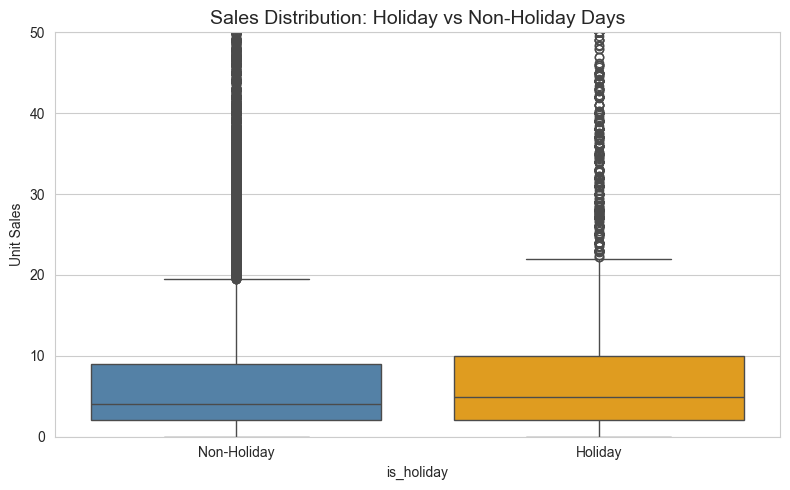

In [4]:
# WHY: if holidays significantly affect sales
# then is_holiday is a valuable feature for our model

holiday_avg = df.groupby("is_holiday")["unit_sales"].mean()
print("Average sales:")
print(f"  Non-holiday days: {holiday_avg[0]:.2f} units")
print(f"  Holiday days:     {holiday_avg[1]:.2f} units")
print(f"  Uplift: {((holiday_avg[1]/holiday_avg[0])-1)*100:.1f}%")

# Box plot
plt.figure(figsize=(8, 5))
df_sample = df.sample(100000, random_state=42)  # sample for speed
sns.boxplot(
    data=df_sample,
    x="is_holiday",
    y="unit_sales",
    palette=["steelblue","orange"]
)
plt.xticks([0, 1], ["Non-Holiday", "Holiday"])
plt.title("Sales Distribution: Holiday vs Non-Holiday Days", fontsize=14)
plt.ylabel("Unit Sales")
plt.ylim(0, 50)  # zoom in — outliers skew the view
plt.tight_layout()
plt.savefig("../outputs/plot_03_holiday_impact.png", dpi=100)
plt.show()

Analysis 4 — Oil Price vs Sales

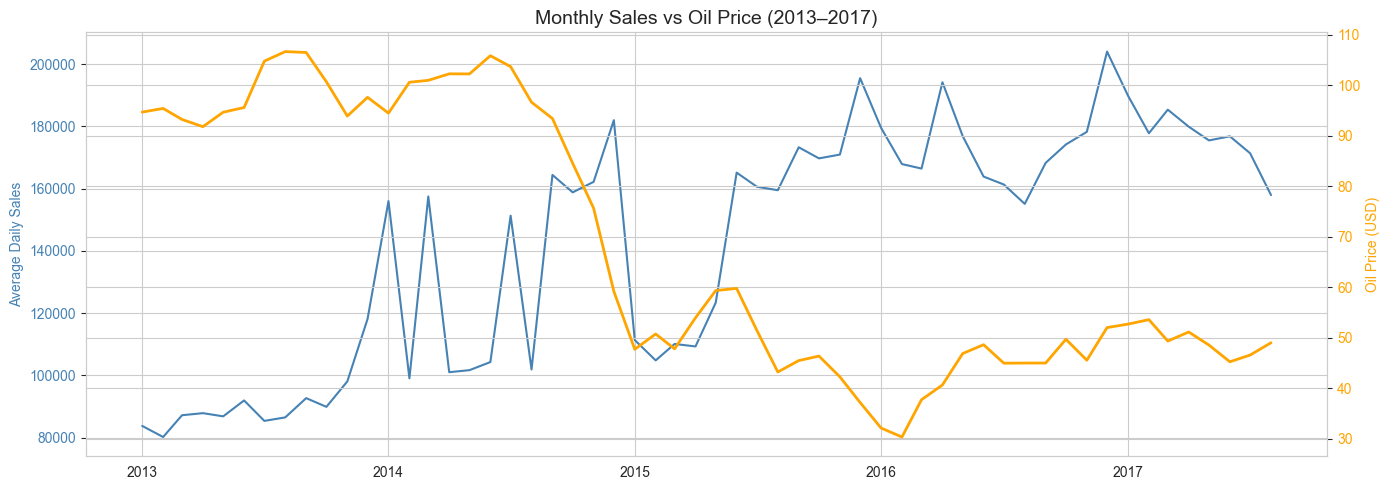

Correlation between daily sales and oil price: -0.600


In [5]:
# WHY: Ecuador's economy depends heavily on oil
# When oil prices drop, consumer spending may change
# This justifies including oil_price as an external regressor

daily = df.groupby("date").agg(
    total_sales=("unit_sales", "sum"),
    oil_price=("oil_price", "mean")
).reset_index()

# Monthly average to smooth noise
daily["month"] = daily["date"].dt.to_period("M")
monthly = daily.groupby("month").agg(
    total_sales=("total_sales", "mean"),
    oil_price=("oil_price", "mean")
).reset_index()
monthly["month"] = monthly["month"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(monthly["month"], monthly["total_sales"],
         color="steelblue", label="Monthly Avg Sales")
ax1.set_ylabel("Average Daily Sales", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["oil_price"],
         color="orange", label="Oil Price", linewidth=2)
ax2.set_ylabel("Oil Price (USD)", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("Monthly Sales vs Oil Price (2013–2017)", fontsize=14)
fig.tight_layout()
plt.savefig("../outputs/plot_04_oil_vs_sales.png", dpi=100)
plt.show()

corr = daily["total_sales"].corr(daily["oil_price"])
print(f"Correlation between daily sales and oil price: {corr:.3f}")

Analysis 5 — Seasonality Decomposition

Analyzing store 1, item 1503844
Series length: 1015 days
Zero sales days: 0


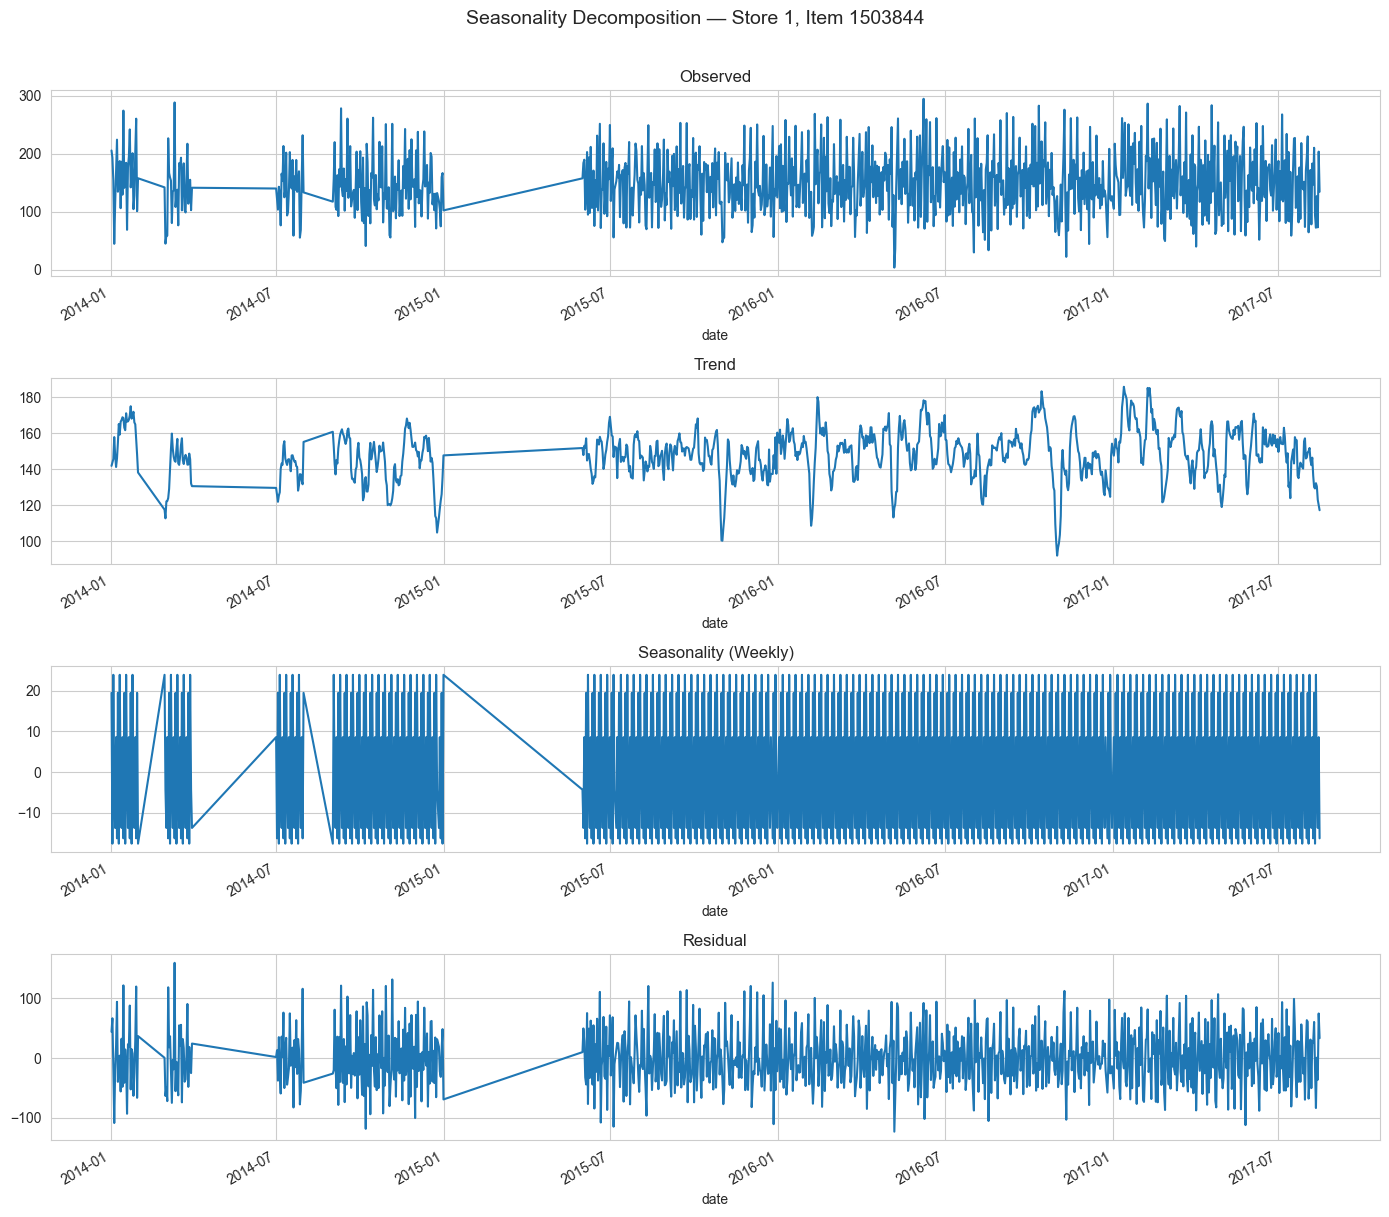

In [6]:
# WHY: decomposition shows us trend, weekly pattern, and residual noise
# This directly tells us which lag features to build
# (weekly pattern → lag_7, monthly pattern → lag_28)

# Pick ONE high-volume store-item pair for this analysis
# Find the top selling item in store 1
top_item = (
    df[df["store_nbr"] == 1]
    .groupby("item_nbr")["unit_sales"]
    .sum()
    .idxmax()
)
print(f"Analyzing store 1, item {top_item}")

series = (
    df[(df["store_nbr"] == 1) & (df["item_nbr"] == top_item)]
    .set_index("date")["unit_sales"]
    .sort_index()
)

print(f"Series length: {len(series)} days")
print(f"Zero sales days: {(series == 0).sum()}")

# Decompose — period=7 means weekly seasonality
decomp = seasonal_decompose(
    series,
    model="additive",
    period=7,
    extrapolate_trend="freq"
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomp.observed.plot(ax=axes[0], title="Observed")
decomp.trend.plot(ax=axes[1], title="Trend")
decomp.seasonal.plot(ax=axes[2], title="Seasonality (Weekly)")
decomp.resid.plot(ax=axes[3], title="Residual")
plt.suptitle(f"Seasonality Decomposition — Store 1, Item {top_item}", 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/plot_05_decomposition.png", dpi=100)
plt.show()

5 Findings:
This is the most important cell in this notebook. After running all plots above, fill this in with your actual observations.

In [9]:
findings = """
FINDING 1 — Sales Trend:
Sales were flat and low through 2013, grew sharply through 2014,
dipped in mid-2015 coinciding with the oil price crash (-0.600
correlation), then recovered strongly through 2016-2017.
Clear repeating spikes indicate strong weekly and annual
seasonality throughout the entire period.

FINDING 2 — Product Families:
GROCERY I dominates with 29.5% of total volume.
Top 5 families (GROCERY I, BEVERAGES, PRODUCE, CLEANING, DAIRY)
account for 78.3% of total sales. Model performance on these
5 families will determine overall forecast quality.

FINDING 3 — Holiday Impact:
Holiday days show 11.4% higher average sales vs non-holiday days.
This is statistically meaningful signal — is_holiday included
as a binary feature in all models.

FINDING 4 — Oil Price Relationship:
Strong negative correlation of -0.600 between daily sales and
oil price. When oil crashed in 2015, total sales declined.
Ecuador is oil-dependent — lower oil revenue reduces consumer
spending. Oil price included as external regressor in both
LightGBM and Prophet.

FINDING 5 — Seasonality:
Decomposition of Store 1, Item 1503844 reveals a strong,
consistent weekly cycle with amplitude of ~20 units.
Pattern is stable from 2015 onward. Trend is flat-to-stable
around 150 units, with a dip in 2015 matching the oil crash.
Residuals range ±100 units — unexplained noise from promotions
and local events. This confirms lag_7 and rolling_mean_7 as
the most critical features in our model.
"""
print(findings)


FINDING 1 — Sales Trend:
Sales were flat and low through 2013, grew sharply through 2014,
dipped in mid-2015 coinciding with the oil price crash (-0.600
correlation), then recovered strongly through 2016-2017.
Clear repeating spikes indicate strong weekly and annual
seasonality throughout the entire period.

FINDING 2 — Product Families:
GROCERY I dominates with 29.5% of total volume.
Top 5 families (GROCERY I, BEVERAGES, PRODUCE, CLEANING, DAIRY)
account for 78.3% of total sales. Model performance on these
5 families will determine overall forecast quality.

FINDING 3 — Holiday Impact:
Holiday days show 11.4% higher average sales vs non-holiday days.
This is statistically meaningful signal — is_holiday included
as a binary feature in all models.

FINDING 4 — Oil Price Relationship:
Strong negative correlation of -0.600 between daily sales and
oil price. When oil crashed in 2015, total sales declined.
Ecuador is oil-dependent — lower oil revenue reduces consumer
spending. Oil price in